# Term Deposit Subscription Prediction
**European Banking | Customer Intention Classification | Telemarketing Optimisation**

---

## Business Context

A European banking institution runs direct marketing campaigns via phone calls to
promote term deposit subscriptions. The current approach contacts customers
indiscriminately, resulting in low conversion rates, wasted agent resources, and
a poor customer experience.

**Goals:**
1. Predict whether a customer will subscribe to a term deposit (`y`)
2. Determine which features most strongly drive subscription decisions

**Success Metric:** 81%+ accuracy via 5-fold cross-validation (average score)
**Key Operational Metric:** Minority-class recall — catching actual subscribers

## Solution Design: Two-Layer Pipeline

Features fall into two groups separated by a temporal boundary:

| Layer | Features Available | Purpose |
|-------|--------------------|---------|
| **Model 1 : Pre-call** | Demographics + financial history | Predict who to call *before* any contact |
| **Model 2 : Post-call** | All features (incl. call data) | Predict who to *continue* calling after contact |

---
## Import Dependencies

In [1]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import random
import duckdb

from src.cluster_model import cluster_subscribers
from src.two_layer_model import (
    load_data, get_feature_sets, explore_data,
    split_data, data_cleaning, encode_data,
    select_model, compare_ensembles, tune_hyperparameters,
    feature_importance, evaluate_model
)

SEED = random.randint(1000, 9999)
print(f"Seed: {SEED}")

ROOT = Path.cwd()
DATA_PATH = ROOT / "data" / "term-deposit-marketing-2020.csv"

Seed: 6595


---
## 1. Data Loading

In [2]:
term_deposit_df = load_data(DATA_PATH)
print(f"Shape: {term_deposit_df.shape[0]:,} rows x {term_deposit_df.shape[1]} columns")
term_deposit_df.head()

Shape: 40,000 rows x 14 columns


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no


---
## 2. Feature Groups

Features are split into pre-call and post-call groups based on when they become available.
`duration` is in the post-call group — it only exists after a call ends and must not
be used in Model 1 (data leakage).

In [3]:
pre_call_cols, post_call_cols = get_feature_sets(term_deposit_df)
all_cols = pre_call_cols + post_call_cols
print(f"Model 1 — Pre-call  : {pre_call_cols}")
print(f"Model 2 adds        : {post_call_cols}")

Model 1 — Pre-call  : ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan']
Model 2 adds        : ['contact', 'day', 'month', 'duration', 'campaign']


---
## 3. Exploratory Data Analysis

EDA covers target distribution, feature distributions by class, numeric histograms,
correlation structure, and identification of structural missing values (`"unknown"`).

       age           job   marital  education default  balance housing loan  \
0       58    management   married   tertiary      no     2143     yes   no   
1       44    technician    single  secondary      no       29     yes   no   
2       33  entrepreneur   married  secondary      no        2     yes  yes   
3       47   blue-collar   married    unknown      no     1506     yes   no   
4       33       unknown    single    unknown      no        1      no   no   
39995   53    technician   married   tertiary      no      395      no   no   
39996   30    management    single   tertiary      no     3340      no   no   
39997   54         admin  divorced  secondary      no      200      no   no   
39998   34    management   married   tertiary      no     1047      no   no   
39999   38    technician   married  secondary      no     1442     yes   no   

        contact  day month  duration  campaign    y  
0       unknown    5   may       261         1   no  
1       unknown    5  

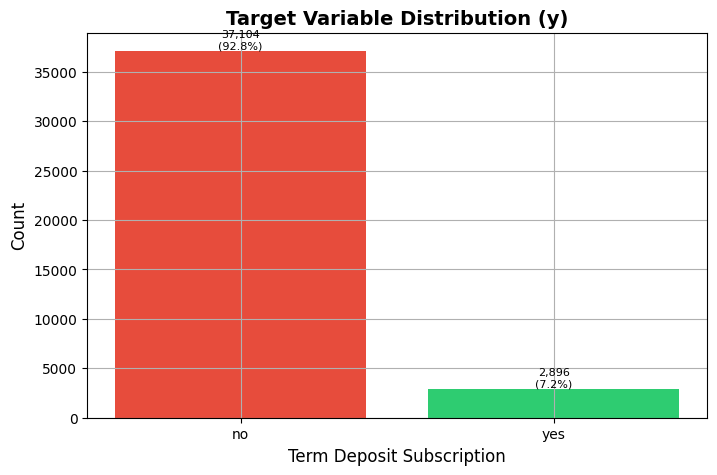


--- job ---
job
blue-collar      9383
management       8166
technician       6852
admin            4483
services         3910
retired          1437
self-employed    1414
entrepreneur     1405
unemployed       1104
housemaid        1087
student           524
unknown           235
Name: count, dtype: int64


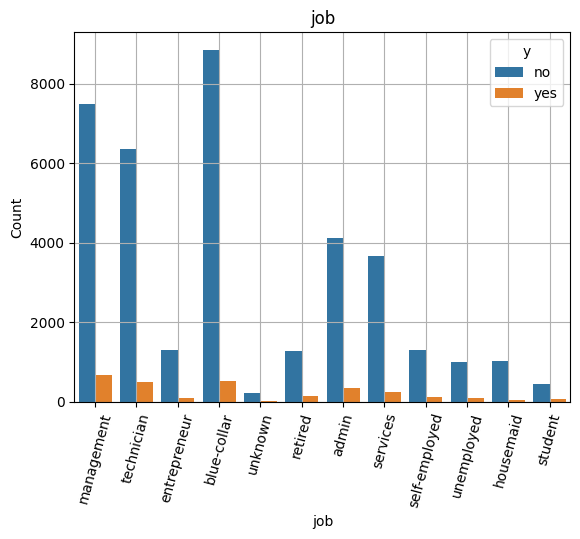


--- marital ---
marital
married     24386
single      10889
divorced     4725
Name: count, dtype: int64


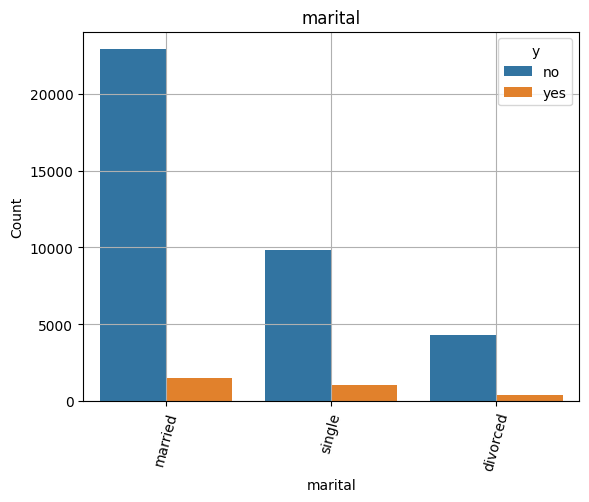


--- education ---
education
secondary    20993
tertiary     11206
primary       6270
unknown       1531
Name: count, dtype: int64


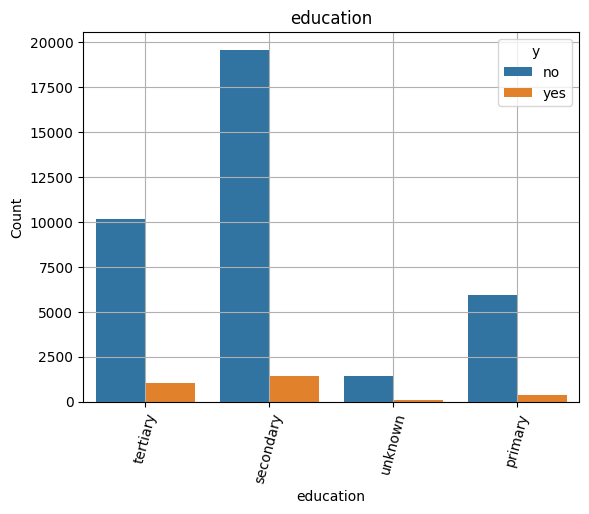


--- default ---
default
no     39191
yes      809
Name: count, dtype: int64


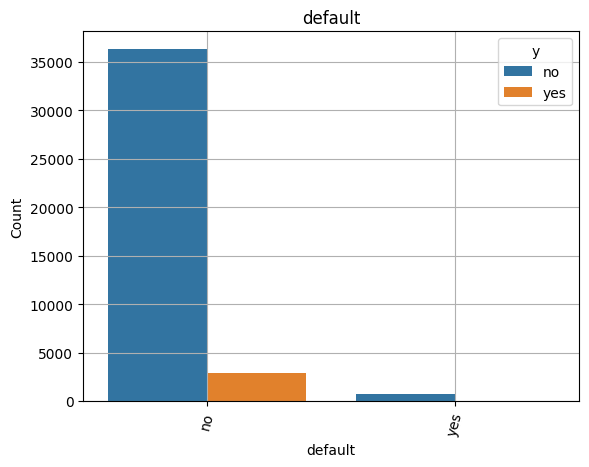


--- housing ---
housing
yes    24031
no     15969
Name: count, dtype: int64


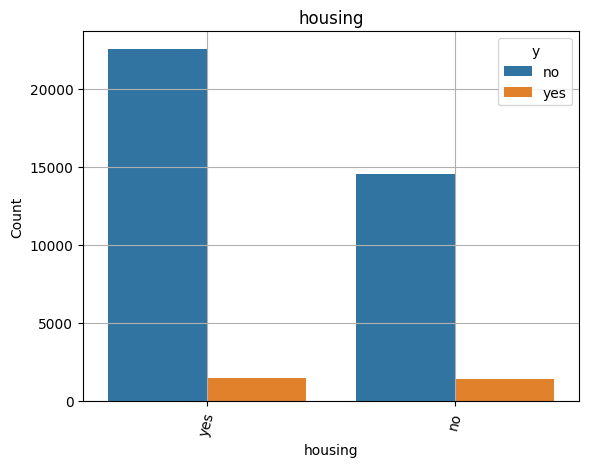


--- loan ---
loan
no     33070
yes     6930
Name: count, dtype: int64


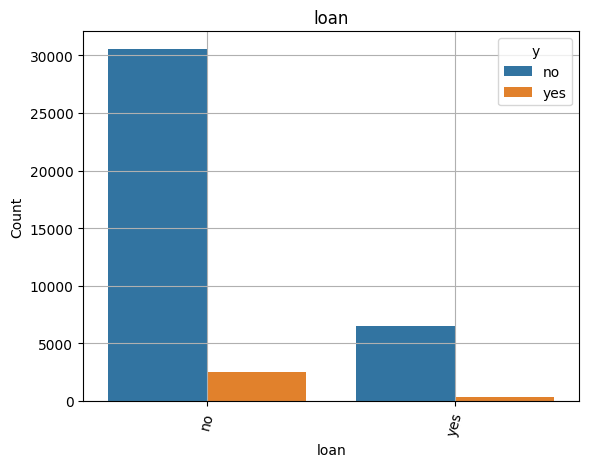


--- contact ---
contact
cellular     24914
unknown      12765
telephone     2321
Name: count, dtype: int64


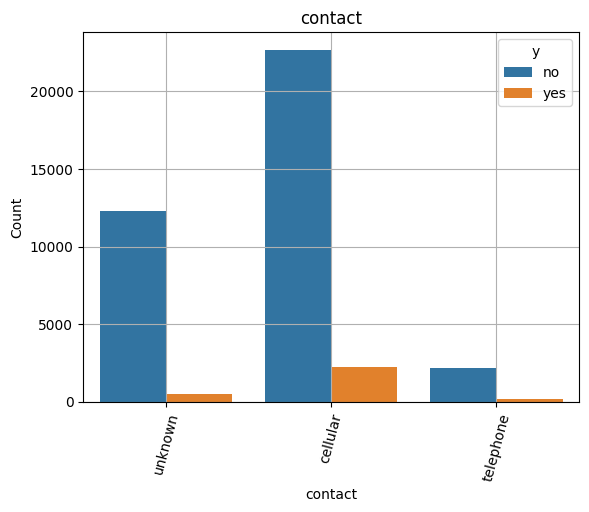


--- month ---
month
may    13532
jul     6380
aug     5215
jun     4734
nov     3598
apr     2718
feb     2296
jan     1176
mar      258
oct       80
dec       13
Name: count, dtype: int64


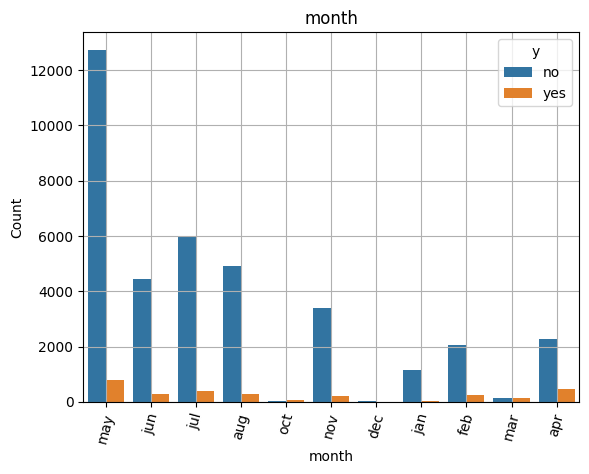


Unknown value counts:
  job: 235 (0.6%)
  education: 1,531 (3.8%)
  contact: 12,765 (31.9%)

Pairwise overlap:
  job & education: 104
  job & contact: 110
  education & contact: 666
  all three: 54

Rows lost if any unknown dropped: 13,705 (34.3%)


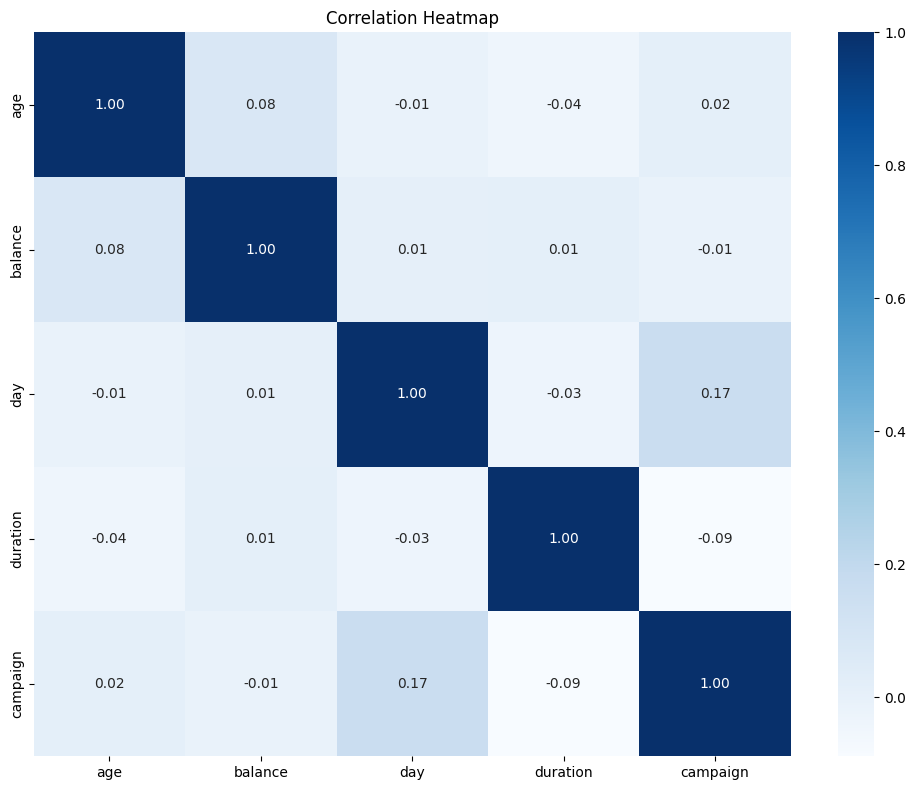

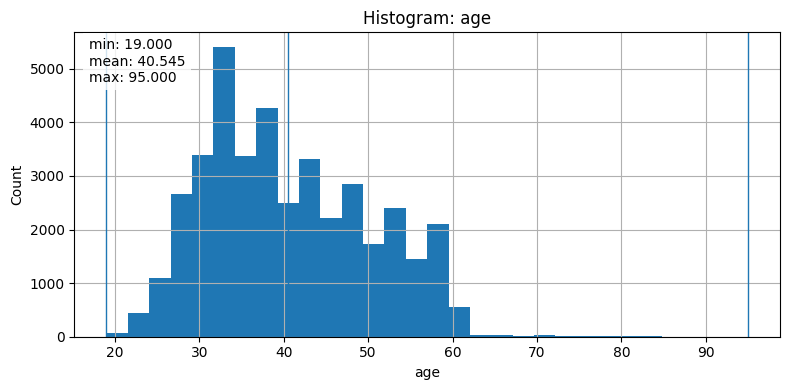

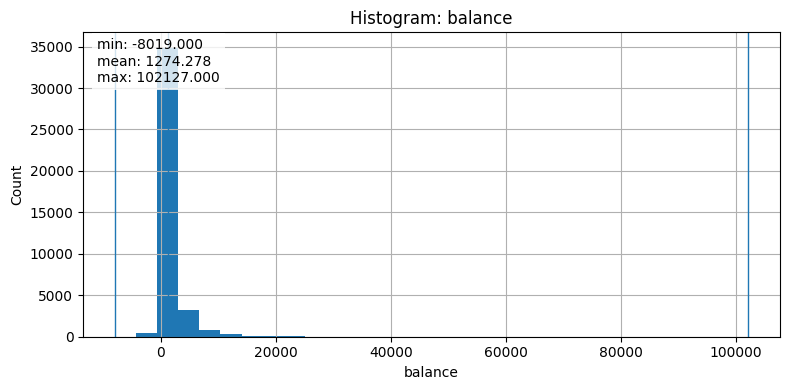

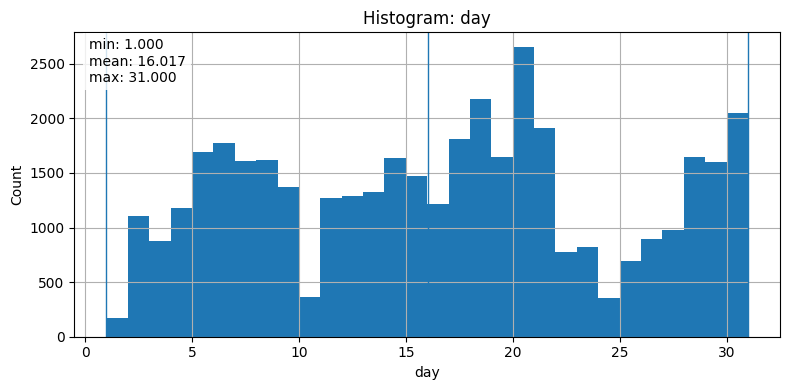

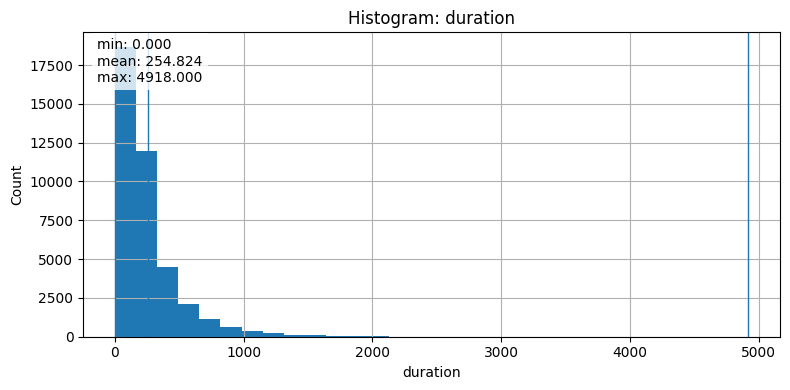

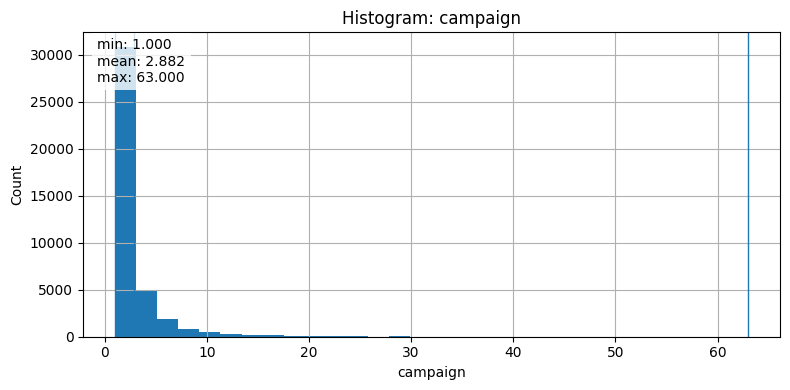

campaign: min=1, max=63 (# contacts this campaign)


In [4]:
numeric_df, categorical_df = explore_data(term_deposit_df)

### Key Findings

#### Class Imbalance

| Class | Count | Share |
|-------|-------|-------|
| No (did not subscribe) | 37104 | 92.8% |
| Yes (subscribed) | 2896 | 7.2% |

The dataset is highly imbalanced. A majority-class classifier achieves 93% accuracy
while being useless to the business. This drives two decisions:
- **Metric:** Optimise for minority-class recall alongside the 81% accuracy target
- **Model config:** `class_weight='balanced'` to penalise missed subscribers

---

#### Numeric Variables

- **`age`:** Range 18–95, mean ~41. No anomalies.
- **`balance`:** Average yearly balance in euros. Can be negative (overdrafts).
  Range −8,019 to 102,127; highly right-skewed with significant outliers.
- **`day`:** Day of month of last contact (1–31). Not a duration. Most calls have been made around 20th
- **`duration`:** Last call duration in seconds. Highly predictive but only known
  *after* the call ends; excluded from Model 1 to prevent data leakage.
- **`campaign`:** Number of contacts made this campaign. Most customers are contacted
  1–3 times; the distribution has a heavy right tail. Maximum value is 63 which seems an outlier.

---

#### Categorical Variables

- **`job`:** Management, blue-collar, and technician are the three most common categories.
- **`marital`:** Married customers are the majority.
- **`education`:** Secondary education is the most frequent level.
- **`default`:** Very few customers have credit in default — a rare event in the dataset.
- **`housing`:** Roughly evenly split between customers with and without a housing loan.
- **`loan`:** Most customers do not hold a personal loan.
- **`contact`:** The majority of contacts were made via cellular. A substantial portion
  of records have an unknown contact type (see table below).
- **`month`:** May has the highest contact volume by a large margin. No calls were made
  in September, suggesting campaign scheduling constraints.

---

#### Structural Missing Values ("unknown")

Pandas reports zero nulls but it is assumed that the missingness is encoded as the string `"unknown"`:

| Column | Count | % of Dataset |
|--------|-------|-------------|
| `contact` | 12,765 | 31.9% |
| `education` | 1,531 | 3.8% |
| `job` | 235 | 0.6% |

**Overlap analysis** — rows where multiple columns are unknown simultaneously:

| Pair | Rows |
|------|------|
| `contact` & `education` | 666 |
| `contact` & `job` | 110 |
| `education` & `job` | 104 |
| All three | 54 |
| Any one (union) | 13,705 (34.3%) |

**Why rows were not dropped:**
Dropping any row containing "unknown" would remove 34.3% of the dataset, nearly all of it
driven by `contact` alone. Given the existing class imbalance, discarding that volume
would significantly reduce minority-class representation in training.

**Design decision — hybrid imputation strategy:**
- **`contact`** → "unknown" retained as a valid category. At 31.9%, this is not random
  missingness but a distinct cohort (customers reached via an unlogged channel). LabelEncoder assigns
  it its own integer; LightGBM can learn from it.
- **`education` and `job`** → mode-imputed. Sparse unknowns (3.8% and 0.6%) with no
  evidence they form a meaningful segment. Mode imputation is simple and introduces
  negligible bias at this volume.

---

#### Outliers

IQR-based clipping `[Q1 − 1.5×IQR, Q3 + 1.5×IQR]` is applied to all numeric features.
Bounds are computed on training data only to prevent leakage.

---
## 4. Preprocessing Pipeline

All transformations are **fitted on training data only**; no leakage at any stage.

| Step | Method | Rationale |
|------|--------|-----------|
| Train / Val / Test split | Stratified 80 / 10 / 10 | Preserves the 93/7 class ratio across all sets |
| `contact` "unknown" | Kept as valid category | 31.9% — informative cohort, not random missingness |
| `education`, `job` "unknown" | Mode imputation | Sparse unknowns; mode fitted on train only |
| Outlier handling | IQR clipping | Reduces outlier influence without removing rows |
| Categorical encoding | `LabelEncoder` | Converts string categories to integers; compatible with all sklearn estimators |
| Numeric scaling | `StandardScaler` | Features span mixed distributions (`balance`, `duration`, `campaign` are skewed; `age` near-normal; `day` uniform). After IQR clipping, extreme outliers are removed; StandardScaler centres and scales each feature to zero mean and unit variance without distortion |
| Target encoding | `LabelEncoder` | `no` → 0, `yes` → 1 |

### Step 4.1 — Train / Validation / Test Split

In [5]:
X_train, X_val, X_test, y_train, y_val, y_test = split_data(
    term_deposit_df, target="y", seed=SEED
)

Train: 32000 | Val: 4000 | Test: 4000


### Step 4.2 — Data Cleaning

Outlier clipping (IQR) fitted on train, applied to val.
Mode imputation for `education` and `job` only; `contact` "unknown" kept as-is.

In [6]:
X_train_cleaned, X_val_cleaned, cat_mode, num_bounds, cat_cols, num_cols = data_cleaning(
    X_train, X_val, categorical_df, numeric_df
)
print("Mode values used for imputation:", cat_mode)

{'job': 'blue-collar', 'marital': 'married', 'education': 'secondary', 'default': 'no', 'housing': 'yes', 'loan': 'no', 'month': 'may'} {'age': (np.float64(10.5), np.float64(70.5)), 'balance': (np.float64(-1836.5), np.float64(3207.5)), 'day': (np.float64(-11.5), np.float64(40.5)), 'duration': (np.float64(-223.5), np.float64(636.5)), 'campaign': (np.float64(-2.0), np.float64(6.0))}
Mode values used for imputation: {'job': 'blue-collar', 'marital': 'married', 'education': 'secondary', 'default': 'no', 'housing': 'yes', 'loan': 'no', 'month': 'may'}


---
## 5. Model Selection

**LazyPredict** benchmarks 30+ classifiers in a single pass, ranked by minority-class
recall on the validation set.

**Selected: LightGBM (`LGBMClassifier`)**

| Criterion | LightGBM |
|-----------|----------|
| Minority-class recall | Consistently top-ranked |
| Class imbalance | Native `class_weight='balanced'` support |
| Interpretability | Feature importance for client-facing insights |
| Speed | Practical for repeated tuning and production retraining |

---
## 6. Hyperparameter Tuning

**Hyperopt** with TPE (Tree-structured Parzen Estimator) performs Bayesian optimisation.
Objective: maximise average minority-class recall across 5-fold cross-validation.

| Parameter | Range | Purpose |
|-----------|-------|---------|
| `n_estimators` | 50–500 | Boosting iterations |
| `max_depth` | 2–8 | Tree depth, controls overfitting |
| `learning_rate` | 0.05–0.2 | Step size shrinkage |
| `num_leaves` | 5–31 | Tree complexity |
| `min_child_samples` | 10–30 | Leaf regularisation |
| `subsample` | 0.7–0.9 | Row sampling |
| `colsample_bytree` | 0.7–0.9 | Feature sampling |

TPE converges in ~50 evaluations by learning from prior trials, where grid search
across this space would require ~1,000+.

---
## 7. Model 1 — Pre-Call Targeting
*Feature set: demographics + financial history only (no call data)*

### Step 7.1 — Encode Features (Model 1)

In [7]:
pre_cat_cols = [c for c in pre_call_cols if c in cat_cols]
pre_num_cols = [c for c in pre_call_cols if c in num_cols]

X_tr_m1, X_va_m1, y_tr_enc, y_va_enc, le1, sc1, le_y1 = encode_data(
    X_train_cleaned[pre_call_cols], X_val_cleaned[pre_call_cols],
    y_train, y_val, pre_cat_cols, pre_num_cols
)
print(f"Model 1 training shape : {X_tr_m1.shape}")
print(f"Features               : {X_tr_m1.columns.tolist()}")

Model 1 training shape : (32000, 8)
Features               : ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan']


### Step 7.2 — Model Selection (Model 1)

In [ ]:
models_df1, _ = select_model(X_tr_m1, X_va_m1, y_tr_enc, y_va_enc)
print(models_df1)

  0%|          | 0/31 [00:00<?, ?it/s]

### Step 7.3 — Ensemble Comparison (Model 1)

Compares tree-based, distance-based, and ensemble strategies via 5-fold CV minority recall.
The best-performing architecture is then carried forward to hyperparameter tuning.

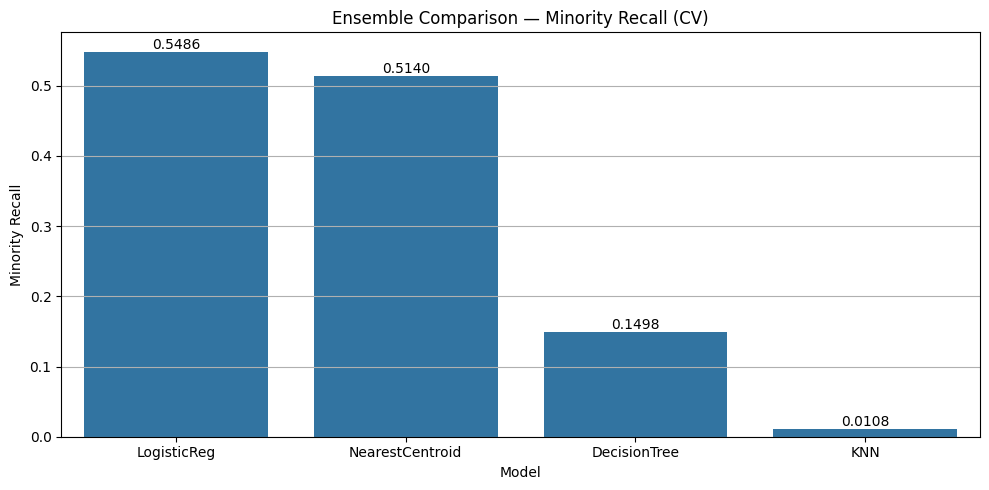

             Model  Minority_Recall
0      LogisticReg             0.55
1  NearestCentroid             0.51
2     DecisionTree             0.15
3              KNN             0.01


In [ ]:
fitted_models1, ensemble_df1 = compare_ensembles(X_tr_m1, y_tr_enc, SEED)
print(ensemble_df1)

### Step 7.4 — Hyperparameter Tuning (Model 1)

In [ ]:
model1, params1, score1 = tune_hyperparameters(X_tr_m1, y_tr_enc, X_va_m1, y_va_enc, SEED)

100%|██████████| 10/10 [00:00<00:00, 15.74trial/s, best loss: -0.5253344217206816]
Best Params: {'metric': 'euclidean', 'shrink_threshold': 0.9142800671528238}
Best Minority Recall (CV): 0.5253


### Step 7.5 — Feature Importance (Model 1)

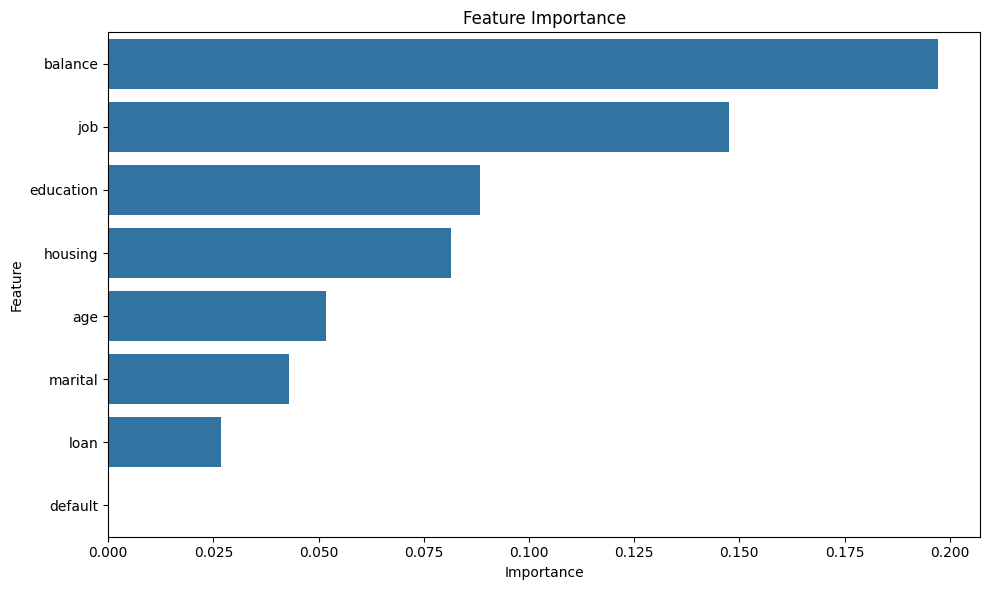

     Feature  Importance
0    balance        0.20
1        job        0.15
2  education        0.09
3    housing        0.08
4        age        0.05
5    marital        0.04
6       loan        0.03
7    default        0.00


In [ ]:
feat1 = feature_importance(X_tr_m1, model1)
print(feat1)

### Step 7.6 — Evaluation on Test Set (Model 1)

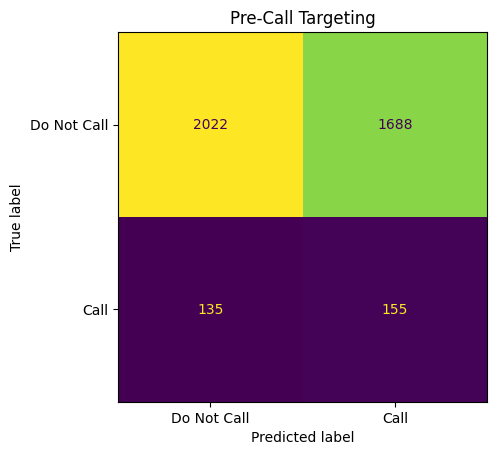

              precision    recall  f1-score   support

          no       0.94      0.55      0.69      3710
         yes       0.08      0.53      0.15       290

    accuracy                           0.54      4000
   macro avg       0.51      0.54      0.42      4000
weighted avg       0.88      0.54      0.65      4000



In [ ]:
report1, cm1 = evaluate_model(
    model1, X_test[pre_call_cols].copy(), y_test,
    le1, sc1, le_y1,
    pre_cat_cols, pre_num_cols, cat_mode, num_bounds, pre_call_cols, "Model1"
)
print(report1)

---
## 8. Model 2 — Post-Call Follow-Up
*Feature set: all features including call data (`duration`, `contact`, `month`, `day`, `campaign`)*

### Step 8.1 — Encode Features (Model 2)

In [ ]:
all_cat_cols = [c for c in all_cols if c in cat_cols]
all_num_cols = [c for c in all_cols if c in num_cols]

X_tr_m2, X_va_m2, y_tr_enc2, y_va_enc2, le2, sc2, le_y2 = encode_data(
    X_train_cleaned[all_cols], X_val_cleaned[all_cols],
    y_train, y_val, all_cat_cols, all_num_cols
)
print(f"Model 2 training shape : {X_tr_m2.shape}")
print(f"Features               : {X_tr_m2.columns.tolist()}")

Model 2 training shape : (32000, 13)
Features               : ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign']


### Step 8.2 — Model Selection (Model 2)

In [ ]:
models_df2, _ = select_model(X_tr_m2, X_va_m2, y_tr_enc2, y_va_enc2)
print(models_df2)

  0%|          | 0/31 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 2317, number of negative: 29683
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000515 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 648
[LightGBM] [Info] Number of data points in the train set: 32000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.072406 -> initscore=-2.550301
[LightGBM] [Info] Start training from score -2.550301

Best model for minority recall: NearestCentroid
                               Accuracy  Balanced Accuracy  ROC AUC  F1 Score  \
Model                                                                           
NearestCentroid                    0.83               0.81     0.81      0.86   
QuadraticDiscriminantAnalysis      0.92               0.71     0.71      0.92   
LinearDiscriminantAnalysis         0.91               0.71     0.71    

### Step 8.3 — Ensemble Comparison (Model 2)

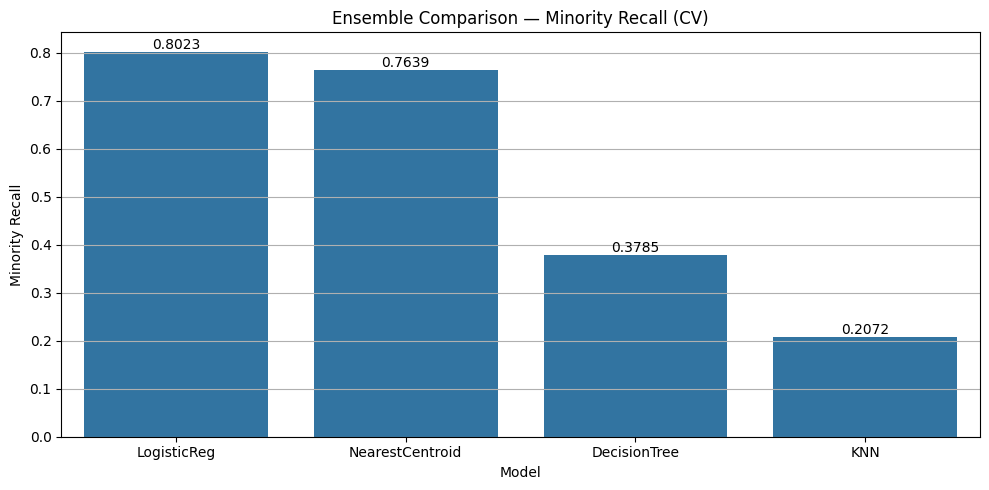

             Model  Minority_Recall
0      LogisticReg             0.80
1  NearestCentroid             0.76
2     DecisionTree             0.38
3              KNN             0.21


In [ ]:
fitted_models2, ensemble_df2 = compare_ensembles(X_tr_m2, y_tr_enc2, SEED)
print(ensemble_df2)

### Step 8.4 — Hyperparameter Tuning (Model 2)

In [ ]:
model2, params2, score2 = tune_hyperparameters(X_tr_m2, y_tr_enc2, X_va_m2, y_va_enc2, SEED)

100%|██████████| 10/10 [00:00<00:00, 13.71trial/s, best loss: -0.8066031283782295]
Best Params: {'metric': 'euclidean', 'shrink_threshold': 0.9142800671528238}
Best Minority Recall (CV): 0.8066


### Step 8.5 — Feature Importance (Model 2)

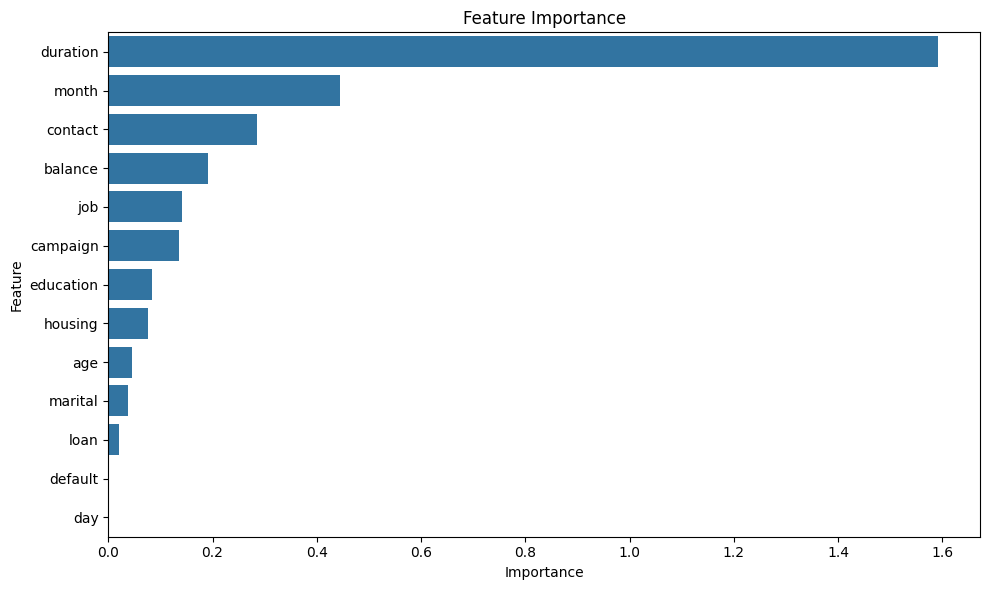

      Feature  Importance
0    duration        1.59
1       month        0.45
2     contact        0.29
3     balance        0.19
4         job        0.14
5    campaign        0.14
6   education        0.08
7     housing        0.08
8         age        0.05
9     marital        0.04
10       loan        0.02
11    default        0.00
12        day        0.00


In [ ]:
feat2 = feature_importance(X_tr_m2, model2)
print(feat2)

### Step 8.6 — Evaluation on Test Set (Model 2)

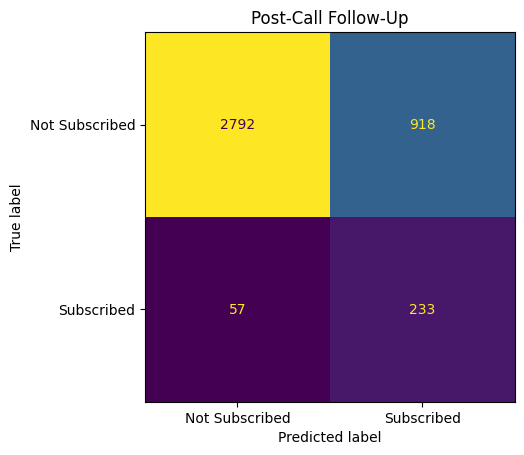

              precision    recall  f1-score   support

          no       0.98      0.75      0.85      3710
         yes       0.20      0.80      0.32       290

    accuracy                           0.76      4000
   macro avg       0.59      0.78      0.59      4000
weighted avg       0.92      0.76      0.81      4000



In [ ]:
report2, cm2 = evaluate_model(
    model2, X_test[all_cols].copy(), y_test,
    le2, sc2, le_y2,
    all_cat_cols, all_num_cols, cat_mode, num_bounds, all_cols, "Model2"
)
print(report2)

---
## 9. Results Summary

In [ ]:
print("Model 1: Who to Call (Pre-Call Targeting)")
print("  Business question : Which customers are worth contacting?")
print(f"  CV Minority Recall : {score1:.4f}")
print("  Feature Importance:")
print(feat1.to_string(index=False))

print("\nModel 2: Who Will Subscribe (Post-Call Follow-Up)")
print("  Business question : Of those contacted, who is likely to subscribe?")
print(f"  CV Minority Recall : {score2:.4f}")
print("  Feature Importance:")
print(feat2.to_string(index=False))

Model 1: Who to Call (Pre-Call Targeting)
  Business question : Which customers are worth contacting?
  CV Minority Recall : 0.5253
  Feature Importance:
  Feature  Importance
  balance        0.20
      job        0.15
education        0.09
  housing        0.08
      age        0.05
  marital        0.04
     loan        0.03
  default        0.00

Model 2: Who Will Subscribe (Post-Call Follow-Up)
  Business question : Of those contacted, who is likely to subscribe?
  CV Minority Recall : 0.8066
  Feature Importance:
  Feature  Importance
 duration        1.59
    month        0.45
  contact        0.29
  balance        0.19
      job        0.14
 campaign        0.14
education        0.08
  housing        0.08
      age        0.05
  marital        0.04
     loan        0.02
  default        0.00
      day        0.00


### Business Impact

In [ ]:
CAMPAIGN_SIZE = 40_000

# Model 1 confusion matrix: rows = actual, cols = predicted
# [TN, FP]   --> actual Do Not Call
# [FN, TP]   --> actual Call (subscriber)
tn1, fp1, fn1, tp1 = cm1.ravel()
total1 = tn1 + fp1 + fn1 + tp1

predicted_no_call   = tn1 + fn1          # model says "Do Not Call"
predicted_call      = tp1 + fp1          # model says "Call"
pct_saved           = predicted_no_call / total1

calls_saved         = int(pct_saved * CAMPAIGN_SIZE)
useless_calls_test  = fp1                # called but won't subscribe
missed_subs_test    = fn1               # missed subscribers
correct_calls_test  = tp1              # correctly targeted

avg_duration_sec     = X_train['duration'].mean()           # avg call duration from train only
avg_duration_min     = avg_duration_sec / 60
hours_saved_test     = predicted_no_call * avg_duration_sec / 3600
hours_saved_campaign = calls_saved * avg_duration_sec / 3600

print(f"Business Impact: Model 1 (Pre-Call Targeting)")
print(f"  Test set size               : {total1:,}")
print(f"  Predicted 'Do Not Call'     : {predicted_no_call:,}  ({100 * pct_saved:.1f}% of test set)")
print(f"  Predicted 'Call'            : {predicted_call:,}")
print()
print(f"  Scaled to {CAMPAIGN_SIZE:,} campaign contacts:")
print(f"    Calls avoided (saved manpower) by the company is : {calls_saved:,}")
print()
print(f"  Average call duration       : {avg_duration_sec:.0f}s  ({avg_duration_min:.1f} min)")
print(f"  Hours saved (test)    : {hours_saved_test:.1f} hours")
print(f"  Hours saved ({CAMPAIGN_SIZE:,})  : {hours_saved_campaign:.0f} hours  ({hours_saved_campaign/8:.0f} working days)")
print()
print(f"  Within the {predicted_call:,} calls made (test set):")
print(f"    Correctly targeted        : {correct_calls_test:,}  (likely subscribers)")
print(f"    Useless calls             : {useless_calls_test:,}  (won't subscribe)")
print(f"    Missed subscribers        : {missed_subs_test:,}  (false negatives)")

Business Impact: Model 1 (Pre-Call Targeting)
  Test set size               : 4,000
  Predicted 'Do Not Call'     : 2,157  (53.9% of test set)
  Predicted 'Call'            : 1,843

  Scaled to 40,000 campaign contacts:
    Calls avoided (saved manpower) by the company is : 21,570

  Average call duration       : 254s  (4.2 min)
  Hours saved (test)    : 152.2 hours
  Hours saved (40,000)  : 1522 hours  (190 working days)

  Within the 1,843 calls made (test set):
    Correctly targeted        : 155  (likely subscribers)
    Useless calls             : 1,688  (won't subscribe)
    Missed subscribers        : 135  (false negatives)


---
## 10. Subscriber Segmentation — KMeans Clustering

In [ ]:
subscribers = duckdb.sql("""
    SELECT *
    FROM term_deposit_df
    WHERE y = 'yes'
""").df()

print(f"Subscribers: {len(subscribers):,}")
cluster_subscribers(subscribers)